# Lab 06 – In-class: Training a Deep Convolutional Neural Network

- Name: ____________________
- Student ID: ______________

## Learning goals

Train a convolutional neural network (CNN) for MNIST, evaluate it with
class-level metrics, inspect errors and feature maps, and demonstrate
transfer learning by reusing a trained convolutional feature extractor.

The workflow follows the subject pattern used in earlier labs:
**inspect → validate → preprocess → model → train → evaluate → interpret**.
The test set stays untouched until final evaluation.


In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
NUM_CLASSES = 10
MAX_TRAINING_SAMPLES = 12_000  # Use None for all 60,000 training images.
CNN_EPOCHS = 4
AUGMENTED_EPOCHS = 4
TRANSFER_EPOCHS = 2
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
keras.utils.set_random_seed(RANDOM_STATE)

print(f"Keras {keras.__version__}; backend: {keras.config.backend()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")


Keras 3.15.1; backend: tensorflow
Output directory: /Users/beam/Workspace/Course/my-cpe-lab/Y3/cpe342/lab06/outputs


## 1. Load and inspect MNIST

MNIST contains 28 × 28 grayscale images labelled from 0 to 9. Check the
schema, value range, class balance, and representative examples before
choosing a model.


In [2]:
(train_images_raw, train_labels), (test_images_raw, test_labels) = (
    keras.datasets.mnist.load_data()
)

assert train_images_raw.shape == (60_000, 28, 28)
assert test_images_raw.shape == (10_000, 28, 28)
assert train_labels.shape == (60_000,)
assert test_labels.shape == (10_000,)
assert train_images_raw.dtype == np.uint8
assert test_images_raw.dtype == np.uint8
assert np.isfinite(train_images_raw).all()
assert np.isfinite(test_images_raw).all()
assert set(np.unique(train_labels)) == set(range(NUM_CLASSES))
assert set(np.unique(test_labels)) == set(range(NUM_CLASSES))

print(f"Training images: {train_images_raw.shape}, dtype={train_images_raw.dtype}")
print(f"Test images: {test_images_raw.shape}, dtype={test_images_raw.dtype}")
print(f"Pixel range: {train_images_raw.min()}–{train_images_raw.max()}")
print(f"Training labels: {train_labels.shape}, dtype={train_labels.dtype}")


Training images: (60000, 28, 28), dtype=uint8
Test images: (10000, 28, 28), dtype=uint8
Pixel range: 0–255
Training labels: (60000,), dtype=uint8


,count
digit,
0,5923
1,6742
2,5958
3,6131
4,5842
5,5421
6,5918
7,6265
8,5851


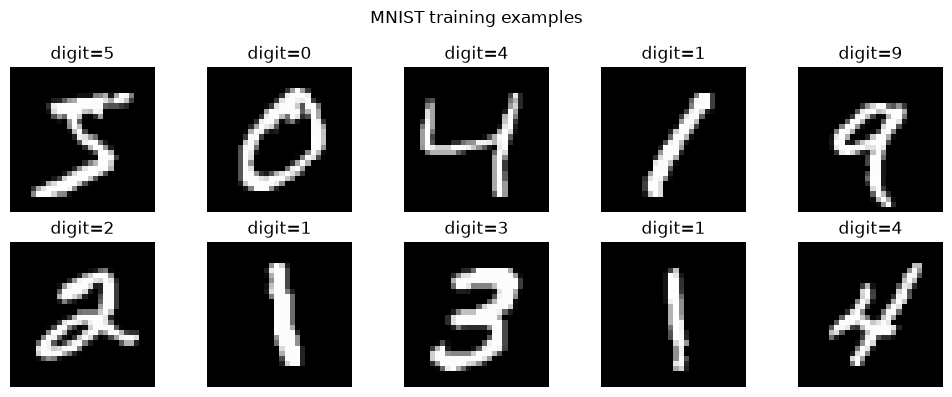

In [3]:
class_counts = (
    pd.Series(train_labels)
    .value_counts()
    .sort_index()
    .rename_axis("digit")
    .to_frame("count")
)
display(class_counts)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for axis, image, label in zip(axes.flat, train_images_raw[:10], train_labels[:10]):
    axis.imshow(image, cmap="gray")
    axis.set_title(f"digit={label}")
    axis.axis("off")
fig.suptitle("MNIST training examples")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mnist_examples.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)


## 2. Preprocess and split the data

Convolutional layers expect `(samples, height, width, channels)`. Add the
grayscale channel, scale pixels from `[0, 255]` to `[0, 1]`, then split
only the original training set. The test set remains isolated.


In [4]:
def preprocess_images(images):
    images = np.asarray(images)
    if images.ndim != 3:
        raise ValueError(f"Expected (samples, height, width); got {images.shape}")
    processed = images[..., np.newaxis].astype("float32") / 255.0
    if not np.isfinite(processed).all() or not (0.0 <= processed).all():
        raise ValueError("Preprocessed pixels must be finite and non-negative")
    if processed.max() > 1.0:
        raise ValueError("Preprocessed pixels must be at most 1")
    return processed


X_all = preprocess_images(train_images_raw)
X_test = preprocess_images(test_images_raw)

# Keep the full test set for evaluation. A configurable training cap makes
# this notebook practical on a CPU while preserving the full-data path.
modeling_images = X_all
modeling_labels = train_labels
if MAX_TRAINING_SAMPLES is not None:
    if MAX_TRAINING_SAMPLES < NUM_CLASSES:
        raise ValueError("MAX_TRAINING_SAMPLES must cover every class")
    rng = np.random.default_rng(RANDOM_STATE)
    selected_indices = rng.choice(
        len(modeling_labels),
        min(MAX_TRAINING_SAMPLES, len(modeling_labels)),
        replace=False,
    )
    modeling_images = modeling_images[selected_indices]
    modeling_labels = modeling_labels[selected_indices]

X_train, X_val, y_train, y_val = train_test_split(
    modeling_images,
    modeling_labels,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=modeling_labels,
)

assert X_train.shape[1:] == (28, 28, 1)
assert X_val.shape[1:] == (28, 28, 1)
assert X_test.shape == (10_000, 28, 28, 1)
assert len(X_train) + len(X_val) == len(modeling_images)
assert set(np.unique(y_train)) == set(range(NUM_CLASSES))
assert np.isclose(X_train.min(), 0.0)
assert X_train.max() <= 1.0

print(f"Train: {X_train.shape}; validation: {X_val.shape}; test: {X_test.shape}")
print(f"Modeling samples: {len(modeling_labels):,} (cap={MAX_TRAINING_SAMPLES})")
print(f"Train pixel range: {X_train.min():.1f}–{X_train.max():.1f}")


Train: (10800, 28, 28, 1); validation: (1200, 28, 28, 1); test: (10000, 28, 28, 1)
Modeling samples: 12,000 (cap=12000)
Train pixel range: 0.0–1.0


## 3. Build a CNN

A convolution reuses local filters across an image. Pooling reduces the
spatial resolution, while the final softmax layer returns ten class
probabilities. The two convolutional blocks below are deliberately
similar to the architecture introduced in class.


In [5]:
def build_cnn(data_augmentation=None):
    model_layers = [keras.Input(shape=(28, 28, 1), name="image")]
    if data_augmentation is not None:
        model_layers.append(data_augmentation)
    model_layers.extend(
        [
            keras.layers.Conv2D(
                16,
                3,
                padding="same",
                activation="relu",
                kernel_initializer="he_normal",
                name="conv_1",
            ),
            keras.layers.Conv2D(
                16,
                3,
                padding="same",
                activation="relu",
                kernel_initializer="he_normal",
                name="conv_2",
            ),
            keras.layers.MaxPooling2D(2, name="pool_1"),
            keras.layers.Dropout(0.25, name="dropout_1"),
            keras.layers.Conv2D(
                32,
                3,
                padding="same",
                activation="relu",
                kernel_initializer="he_normal",
                name="conv_3",
            ),
            keras.layers.Conv2D(
                32,
                3,
                padding="same",
                activation="relu",
                kernel_initializer="he_normal",
                name="conv_4",
            ),
            keras.layers.MaxPooling2D(2, name="pool_2"),
            keras.layers.Dropout(0.25, name="dropout_2"),
            keras.layers.Flatten(name="flatten"),
            keras.layers.Dense(
                64,
                activation="relu",
                kernel_initializer="he_normal",
                name="features",
            ),
            keras.layers.Dropout(0.5, name="dropout_3"),
            keras.layers.Dense(
                NUM_CLASSES,
                activation="softmax",
                name="class_probabilities",
            ),
        ]
    )
    model = keras.Sequential(model_layers, name="mnist_cnn")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )
    return model


cnn = build_cnn()
cnn.summary()


Model: "mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 28, 28, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,434 (458.73 KB)

 Trainable params: 117,434 (458.73 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train the CNN

Use validation loss for early stopping and restore the best weights. This
limits overfitting without using the test set to choose an epoch.


In [6]:
keras.utils.set_random_seed(RANDOM_STATE)
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history = cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=CNN_EPOCHS,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=2,
)

history_frame = pd.DataFrame(history.history)
best_epoch = int(history_frame["val_loss"].idxmin() + 1)
print(f"Best validation loss: epoch {best_epoch}")


Epoch 1/4


85/85 - 4s - 42ms/step - accuracy: 0.4743 - loss: 1.5204 - val_accuracy: 0.9050 - val_loss: 0.4524


Epoch 2/4


85/85 - 3s - 37ms/step - accuracy: 0.7902 - loss: 0.6338 - val_accuracy: 0.9467 - val_loss: 0.1999


Epoch 3/4


85/85 - 5s - 56ms/step - accuracy: 0.8655 - loss: 0.4132 - val_accuracy: 0.9517 - val_loss: 0.1551


Epoch 4/4


85/85 - 3s - 34ms/step - accuracy: 0.8968 - loss: 0.3283 - val_accuracy: 0.9675 - val_loss: 0.1210


Best validation loss: epoch 4


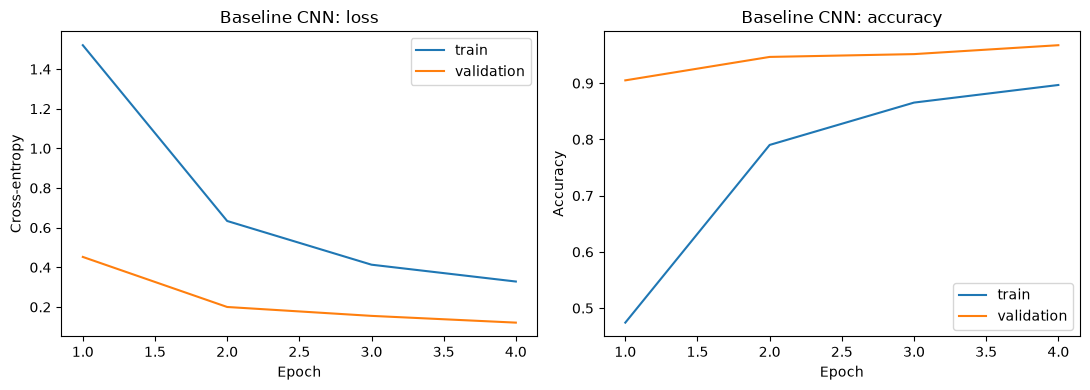

,accuracy,loss,val_accuracy,val_loss
0,0.4743,1.5204,0.9050,0.4524
1,0.7902,0.6338,0.9467,0.1999
2,0.8655,0.4132,0.9517,0.1551
3,0.8968,0.3283,0.9675,0.1210


In [7]:
def plot_history(history, title, output_name):
    frame = pd.DataFrame(history.history)
    epochs = np.arange(1, len(frame) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(epochs, frame["loss"], label="train")
    axes[0].plot(epochs, frame["val_loss"], label="validation")
    axes[0].set(title=f"{title}: loss", xlabel="Epoch", ylabel="Cross-entropy")
    axes[0].legend()

    axes[1].plot(epochs, frame["accuracy"], label="train")
    axes[1].plot(epochs, frame["val_accuracy"], label="validation")
    axes[1].set(title=f"{title}: accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / output_name, dpi=150, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return frame


history_frame = plot_history(history, "Baseline CNN", "mnist_cnn_history.png")
display(history_frame.round(4))


## 5. Evaluate the model

Report accuracy together with precision, recall, and F1. A confusion
matrix shows which digit pairs are difficult. These values are computed
once on the untouched test set.


In [8]:
test_loss, test_accuracy = cnn.evaluate(X_test, test_labels, verbose=0)
test_probabilities = cnn.predict(X_test, batch_size=256, verbose=0)
predicted_labels = np.argmax(test_probabilities, axis=1)

report = classification_report(
    test_labels,
    predicted_labels,
    labels=np.arange(NUM_CLASSES),
    output_dict=True,
    zero_division=0,
)
report_frame = pd.DataFrame(report).T
report_frame.index.name = "class"

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
display(report_frame.round(4))
assert 0.0 <= test_accuracy <= 1.0
assert test_accuracy > 0.90, "The CNN should exceed a 0.90 test accuracy"


Test loss: 0.1066
Test accuracy: 0.9667


,precision,recall,f1-score,support
class,,,,
0,0.9671,0.9908,0.9788,980.0000
1,0.9833,0.9859,0.9846,1135.0000
2,0.9482,0.9748,0.9613,1032.0000
3,0.9712,0.9683,0.9698,1010.0000
4,0.9842,0.9501,0.9668,982.0000
5,0.9597,0.9888,0.9740,892.0000
6,0.9781,0.9781,0.9781,958.0000
7,0.9681,0.9436,0.9557,1028.0000
8,0.9724,0.9405,0.9562,974.0000


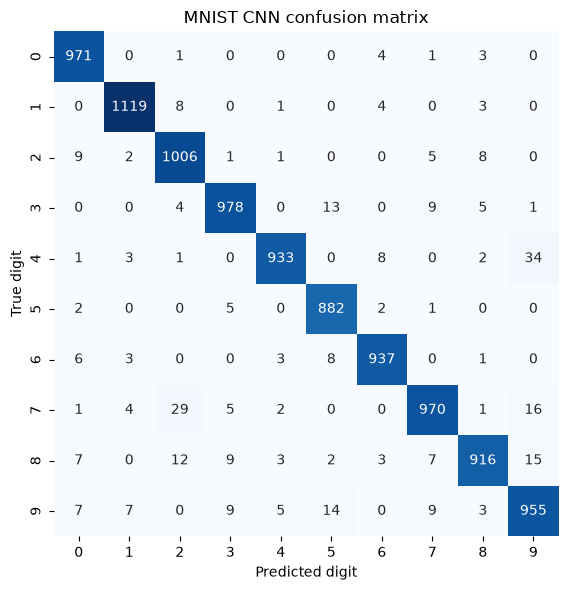

In [9]:
confusion = confusion_matrix(
    test_labels,
    predicted_labels,
    labels=np.arange(NUM_CLASSES),
)
fig, axis = plt.subplots(figsize=(7, 6))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    ax=axis,
)
axis.set(
    title="MNIST CNN confusion matrix",
    xlabel="Predicted digit",
    ylabel="True digit",
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mnist_cnn_confusion_matrix.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)


### 5.1 Inspect incorrect predictions

The plot below makes the numeric errors concrete. Look for visually
ambiguous handwriting and record which true/predicted pairs occur most.


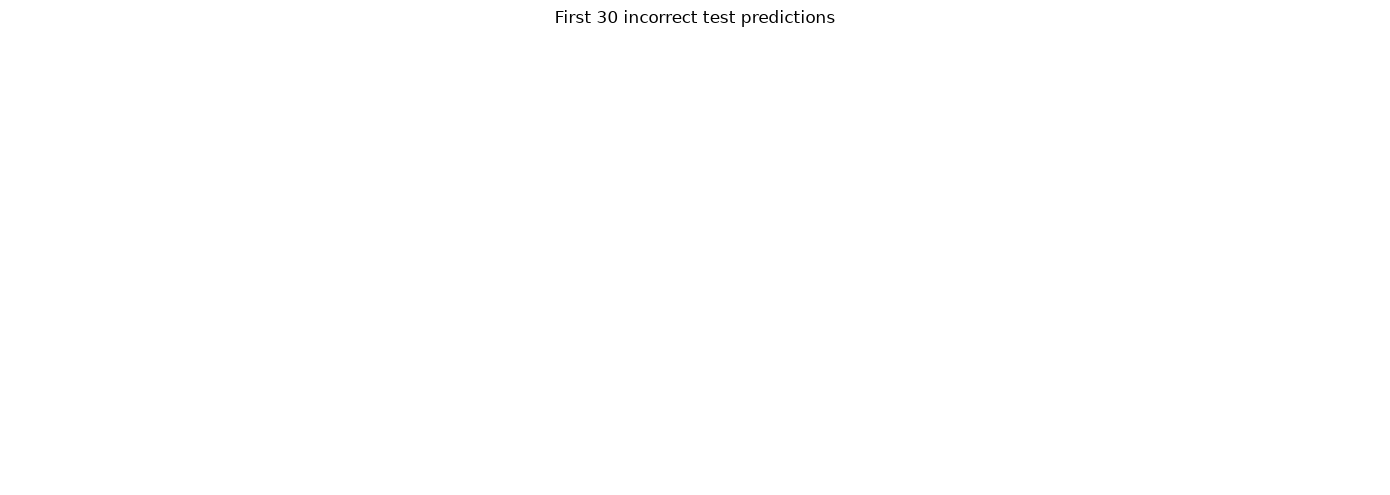

count
true predicted       
4    9             34
7    2             29
     9             16
8    9             15
9    5             14
3    5             13
8    2             12
9    7              9
3    7              9
9    3              9

In [10]:
wrong_indices = np.flatnonzero(predicted_labels != test_labels)
n_images = min(30, len(wrong_indices))
fig, axes = plt.subplots(3, 10, figsize=(14, 5))
axes = axes.flat

for axis in axes:
    axis.axis("off")
for axis, index in zip(axes, wrong_indices[:n_images]):
    axis.imshow(test_images_raw[index], cmap="gray")
    axis.set_title(
        f"pred={predicted_labels[index]}\ntrue={test_labels[index]}",
        fontsize=8,
    )
    axis.axis("off")

fig.suptitle(f"First {n_images} incorrect test predictions")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mnist_cnn_misclassified.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

pair_counts = (
    pd.DataFrame(
        {"true": test_labels[wrong_indices], "predicted": predicted_labels[wrong_indices]}
    )
    .value_counts()
    .rename("count")
    .head(10)
    .to_frame()
)
display(pair_counts)


**Discussion.** Convolutional filters preserve local spatial structure,
so the network can recognize strokes and their combinations instead of
treating every pixel as an unrelated feature. Errors usually occur
between digits with similar loops or slants, such as 4/9 or 3/5. The
confusion matrix and examples above are evidence for the specific pairs;
they do not imply that the model understands the semantic meaning of a
digit.


### 5.2 Data augmentation

Augmentation creates plausible variations during training. For MNIST,
small rotations and translations are reasonable; horizontal flips are not
because they can change the digit's meaning. The random layers run only
when `training=True`, so validation and test images are not modified.


In [11]:
mnist_augmentation = keras.Sequential(
    [
        keras.layers.RandomRotation(0.08, fill_mode="constant"),
        keras.layers.RandomTranslation(0.10, 0.10, fill_mode="constant"),
        keras.layers.RandomZoom(0.10, fill_mode="constant"),
    ],
    name="mnist_augmentation",
)

keras.utils.set_random_seed(RANDOM_STATE)
augmented_cnn = build_cnn(data_augmentation=mnist_augmentation)
augmented_history = augmented_cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=AUGMENTED_EPOCHS,
    batch_size=128,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
        )
    ],
    verbose=2,
)


Epoch 1/4


85/85 - 4s - 45ms/step - accuracy: 0.2842 - loss: 2.0100 - val_accuracy: 0.8267 - val_loss: 0.7317


Epoch 2/4


85/85 - 3s - 35ms/step - accuracy: 0.5750 - loss: 1.2351 - val_accuracy: 0.9467 - val_loss: 0.2584


Epoch 3/4


85/85 - 3s - 35ms/step - accuracy: 0.6991 - loss: 0.8996 - val_accuracy: 0.9475 - val_loss: 0.1725


Epoch 4/4


85/85 - 4s - 52ms/step - accuracy: 0.7581 - loss: 0.7369 - val_accuracy: 0.9517 - val_loss: 0.1542


,test_loss,test_accuracy
model,,
baseline CNN,0.1066,0.9667
CNN + augmentation,0.1081,0.9673


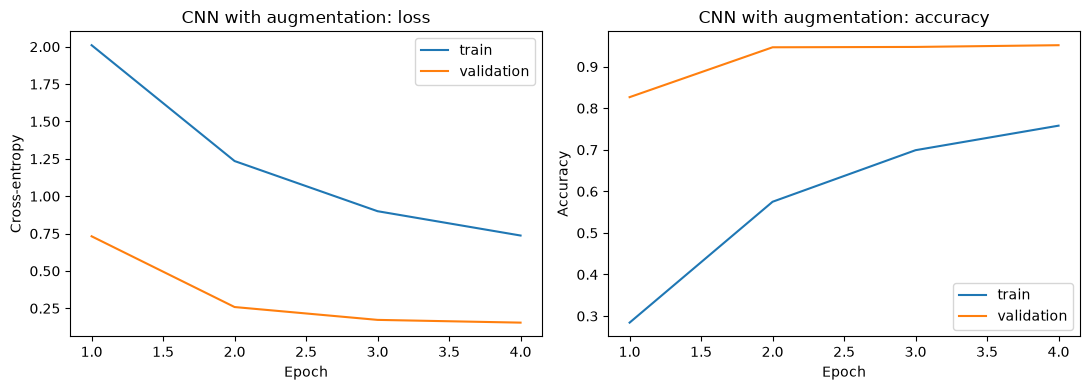

,accuracy,loss,val_accuracy,val_loss
0,0.284167,2.010046,0.826667,0.731734
1,0.575000,1.235124,0.946667,0.258447
2,0.699074,0.899569,0.947500,0.172540
3,0.758056,0.736860,0.951667,0.154195


In [12]:
augmented_loss, augmented_accuracy = augmented_cnn.evaluate(
    X_test, test_labels, verbose=0
)
augmented_probabilities = augmented_cnn.predict(
    X_test, batch_size=256, verbose=0
)
augmented_predictions = np.argmax(augmented_probabilities, axis=1)
comparison = pd.DataFrame(
    [
        {
            "model": "baseline CNN",
            "test_loss": test_loss,
            "test_accuracy": test_accuracy,
        },
        {
            "model": "CNN + augmentation",
            "test_loss": augmented_loss,
            "test_accuracy": augmented_accuracy,
        },
    ]
).set_index("model")
display(comparison.round(4))
plot_history(augmented_history, "CNN with augmentation", "mnist_augmented_history.png")


**Interpretation.** Compare the two test rows rather than assuming that
augmentation always wins. On a simple, aligned dataset such as MNIST,
the baseline can already generalize well; augmentation is most useful
when the expected deployment images contain the variations being added.


## 6. Visualize convolutional layer activations

An intermediate model exposes the outputs of the convolutional layers
while keeping the trained weights unchanged. Early maps often respond to
edges and stroke directions; deeper maps combine those responses into
larger digit patterns.


In [13]:
activation_layer_names = ["conv_1", "conv_2", "conv_3", "conv_4"]
activation_model = keras.Model(
    inputs=cnn.inputs,
    outputs=[cnn.get_layer(name).output for name in activation_layer_names],
    name="mnist_activation_model",
)
example_index = 0
activations = activation_model.predict(
    X_test[example_index : example_index + 1], verbose=0
)
print(
    f"True label: {test_labels[example_index]}; "
    f"predicted label: {predicted_labels[example_index]}"
)
print([activation.shape for activation in activations])


True label: 7; predicted label: 7
[(1, 28, 28, 16), (1, 28, 28, 16), (1, 14, 14, 32), (1, 14, 14, 32)]


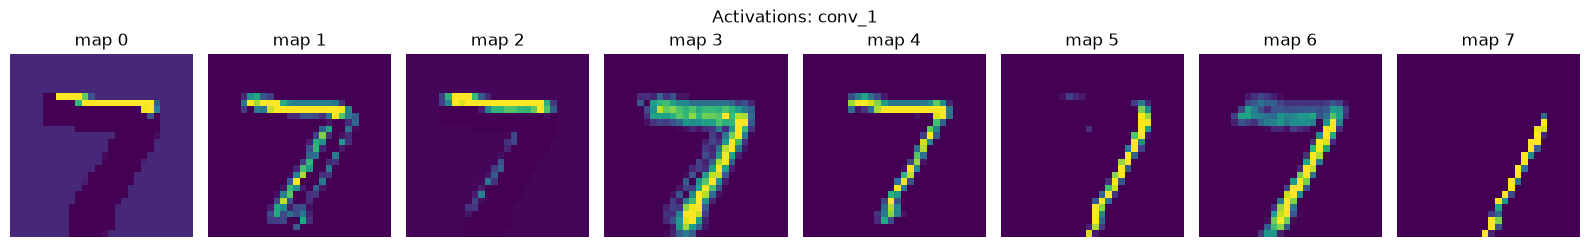

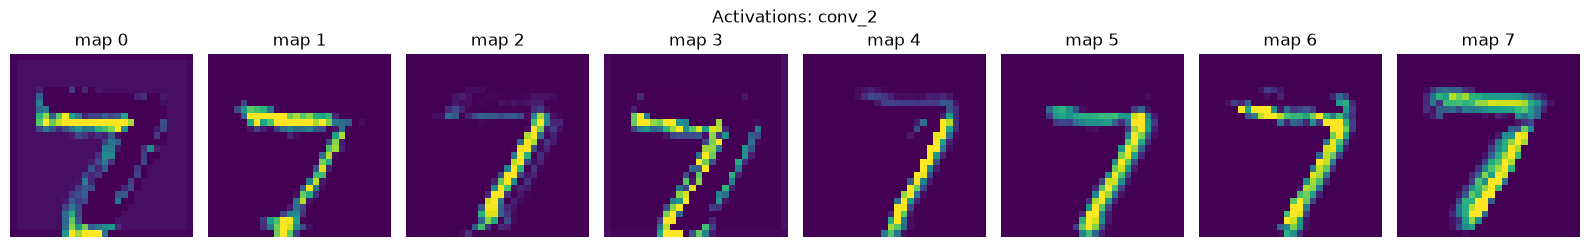

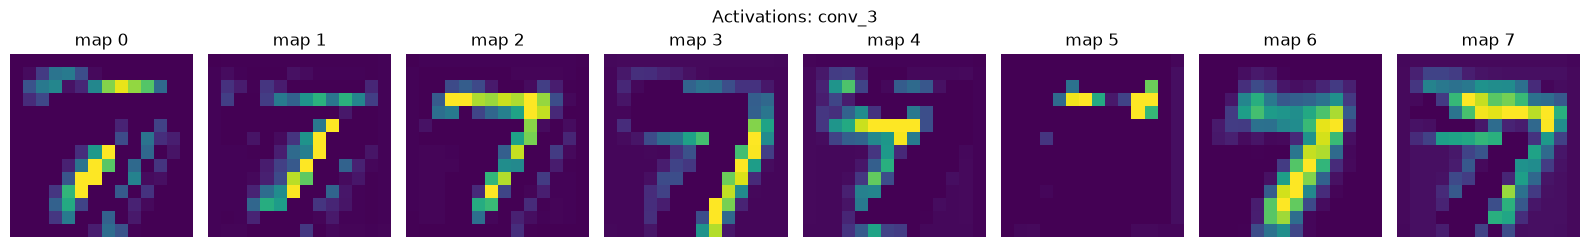

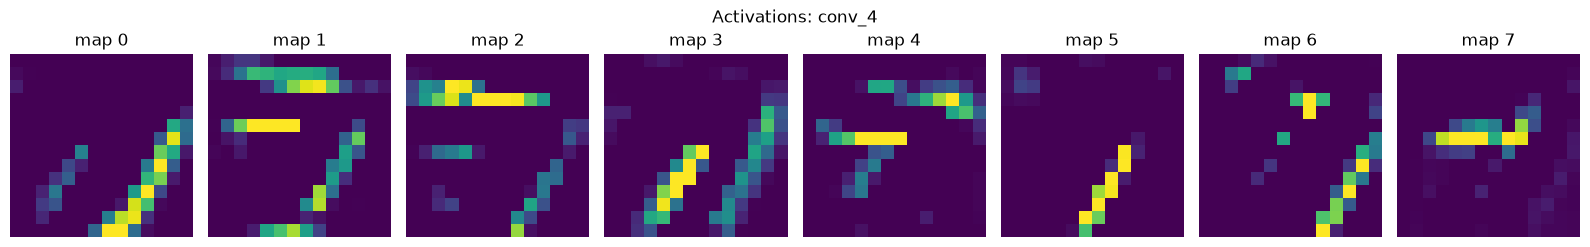

In [14]:
def display_activation_maps(activation, layer_name, max_channels=8):
    n_channels = min(max_channels, activation.shape[-1])
    fig, axes = plt.subplots(1, n_channels, figsize=(2 * n_channels, 2.5))
    axes = np.atleast_1d(axes)
    for channel, axis in enumerate(axes):
        values = activation[0, :, :, channel]
        low, high = np.percentile(values, [2, 98])
        if np.isclose(low, high):
            low, high = None, None
        axis.imshow(values, cmap="viridis", vmin=low, vmax=high)
        axis.set_title(f"map {channel}")
        axis.axis("off")
    fig.suptitle(f"Activations: {layer_name}")
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"activation_{layer_name}.png",
        dpi=150,
        bbox_inches="tight",
    )
    display(fig)
    plt.close(fig)


for name, activation in zip(activation_layer_names, activations):
    display_activation_maps(activation, name)


**Observation.** A single activation map is not a complete explanation of
a prediction. It is a diagnostic view of intermediate representations;
compare several inputs and layers before drawing conclusions.


## 7. Transfer learning

A trained model can supply a feature extractor for a new classifier. This
example reuses the convolutional part of the MNIST CNN and freezes it
while a new classification head is trained. The source and target domain
are both MNIST here, so this demonstrates the mechanics rather than a
realistic domain transfer.


In [15]:
feature_extractor = keras.Model(
    inputs=cnn.inputs,
    outputs=cnn.get_layer("pool_2").output,
    name="frozen_mnist_convolutional_base",
)
feature_extractor.trainable = False

transfer_inputs = keras.Input(shape=(28, 28, 1), name="image")
transfer_features = feature_extractor(transfer_inputs, training=False)
transfer_features = keras.layers.Flatten(name="transfer_flatten")(transfer_features)
transfer_features = keras.layers.Dense(128, activation="relu", name="transfer_dense")(
    transfer_features
)
transfer_outputs = keras.layers.Dense(
    NUM_CLASSES, activation="softmax", name="transfer_probabilities"
)(transfer_features)
transfer_cnn = keras.Model(transfer_inputs, transfer_outputs, name="mnist_transfer_cnn")
transfer_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

print(f"Frozen base layers: {sum(not layer.trainable for layer in feature_extractor.layers)}")
print(f"Trainable transfer parameters: {transfer_cnn.count_params():,}")
transfer_cnn.summary()


Frozen base layers: 8
Trainable transfer parameters: 218,490


Model: "mnist_transfer_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frozen_mnist_convolutional_base │ (None, 7, 7, 32)       │        16,368 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_flatten (Flatten)      │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_dense (Dense)          │ (None, 128)            │       200,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_probabilities (Dense)  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,490 (853.48 KB)

 Trainable params: 202,122 (789.54 KB)

 Non-trainable params: 16,368 (63.94 KB)

In [16]:
keras.utils.set_random_seed(RANDOM_STATE)
transfer_history = transfer_cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=TRANSFER_EPOCHS,
    batch_size=128,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=1,
            restore_best_weights=True,
        )
    ],
    verbose=2,
)
transfer_loss, transfer_accuracy = transfer_cnn.evaluate(
    X_test, test_labels, verbose=0
)
print(f"Frozen-feature test loss: {transfer_loss:.4f}")
print(f"Frozen-feature test accuracy: {transfer_accuracy:.4f}")


Epoch 1/2


85/85 - 2s - 21ms/step - accuracy: 0.9212 - loss: 0.2486 - val_accuracy: 0.9608 - val_loss: 0.1139


Epoch 2/2


85/85 - 1s - 11ms/step - accuracy: 0.9738 - loss: 0.0806 - val_accuracy: 0.9700 - val_loss: 0.0875


Frozen-feature test loss: 0.0661
Frozen-feature test accuracy: 0.9769


To fine-tune selectively, unfreeze only later convolutional layers, use a
much smaller learning rate, recompile, and validate again. Earlier layers
usually learn general visual primitives; later layers are more
task-specific. The following cell shows that pattern without changing the
reported baseline results.


In [17]:
for layer in feature_extractor.layers:
    layer.trainable = layer.name == "conv_4"

trainable_names = [layer.name for layer in feature_extractor.layers if layer.trainable]
print(f"Selective fine-tuning layers: {trainable_names}")
print("Recompile with a small learning rate before fine-tuning this model.")


Selective fine-tuning layers: ['conv_4']
Recompile with a small learning rate before fine-tuning this model.


## Conclusion

The CNN learns spatial features that a fully connected network ignores.
Final conclusions should cite the measured test accuracy, the largest
confusion-matrix errors, the effect of augmentation, and the limits of
activation visualizations. Keep the test set for this final report only.
